# Machine Learning for Multibody System Dynamics

## **Session 2-2:** Surrogate Modeling – Duffing Oscillator with External Forcing

Grzegorz Orzechowski & Peter Manzl

> DNN trained on Duffing‐oscillator dynamics with randomized forces or harmonics.

## From 2-1 to 2-2: A Key Shift

In **2-1** we had access to the *equations of motion* and could sample the state space directly.  
In practice, equations are often **unavailable or too complex** — we only have simulation runs or measurements.

### New mapping

| | 2-1 (local) | 2-2 (trajectory) |
|--|-------------|-----------------|
| **Input** | $(x, v, F)$ — one state | $(x_0, v_0, \hat{f}_0,\dots,\hat{f}_{63})$ — full sequence |
| **Output** | $(\dot{x}, \dot{v})$ — one step | $(x_1, x_2,\dots, x_{64})$ — full trajectory |
| **Problem** | rollout error accumulates | predicted in one shot — no accumulation |

This sidesteps the **rollout error problem** from 2-1 by design.

### Trade-offs of the Trajectory Approach

**Advantages:**
- No error accumulation — full trajectory predicted at once
- Works without equations of motion
- Forces and initial conditions are co-embedded in the input

**Disadvantages:**
- Fixed time horizon — must match training length exactly
- Much larger input vector: $2 + 64 = 66$ features vs $3$ in 2-1
- Requires integration runs to generate training data (slower)
- Extrapolation in time is not possible

## Problem Setup

Same Duffing oscillator as in 2-1:

$$m \,\ddot{x} + d \,\dot{x} + k \,x + \alpha \,k \,x^3 = F(t), \quad m=1,\; k=1600,\; d=8,\; \alpha=1.$$

**Trajectory discretization:**
- Time step: $h = 0.5/64$
- Steps per trajectory: $n = 64$
- Total time: $T = 0.5$ s

**Input normalization:** forces are pre-scaled to $[-1, 1]$ by dividing by 2000:

$$\hat{f}_i = F_i / 2000$$

This is a simpler alternative to `StandardScaler` — valid when you know the force range in advance.

In [1]:
# 1) Imports & Device Setup
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Problem Setup

- Time step: $h = \tfrac{0.5}{64}$.
- Number of steps per trajectory: $n = 64$.
- Total integration time: $T = n \times h = 0.5$ s.
- Time vector: $t_i = i\,h$ for $i=0,\dots,n$.

Define constants and the Duffing ODE (second-order rewritten as first-order).

In [2]:
# 2) Constants & time grid
m, k, damp, alpha = 1.0, 1600.0, 8.0, 1.0
n_steps = 64
h       = 0.5 / n_steps
T       = h * n_steps
t_steps = np.linspace(0, T, n_steps+1)

In [3]:
# 3) Duffing RHS (first-order form)
def duffing_rhs(t, u, forces):
    # u = [x, v]
    idx = min(int(t / h), len(forces)-1)
    F_t = forces[idx]
    x, v = u
    dx = v
    dv = F_t - damp * v - k * x - alpha * k * x**3
    return [dx, dv]

## Two Datasets: Why?

A surrogate trained only on one forcing type may **fail to generalize** to others.

| Dataset | Forcing type | Samples | Physical relevance |
|---------|-------------|---------|-------------------|
| **1** | Random step sequences | 2 000 | shock loads, impact |
| **2** | Harmonic $A\sin(\omega t)$ | 2 000 | rotating machinery, periodic excitation |

Training on both gives the model exposure to qualitatively different dynamics.  

> **Discussion:** Would you expect a model trained only on random forces to predict harmonic responses well? Why or why not?

### Dataset 1: Randomized Force Sequences

For each of 2 000 samples:
1. Random initial state $(x_0, \dot{x}_0) \in [-1, 1]$
2. Random piecewise-constant force $F_i \sim \mathcal{U}(-2000, 2000)$ for $i = 0,\dots,63$
3. Normalize: $\hat{f}_i = F_i / 2000$
4. Integrate ODE → record positions $x_1, \dots, x_{64}$

In [4]:
# 4) Dataset 1
rng = np.random.default_rng(123)
N1 = 2000

inputs1  = np.zeros((N1, 2 + n_steps), dtype=np.float32)
targets1 = np.zeros((N1, n_steps),    dtype=np.float32)

for i in range(N1):
    x0 = rng.random()*2 - 1
    v0 = rng.random()*2 - 1
    F_seq = rng.random(n_steps)*4000 - 2000
    fhat  = F_seq / 2000.0

    inputs1[i, 0]   = x0
    inputs1[i, 1]   = v0
    inputs1[i, 2:]  = fhat

    sol = solve_ivp(lambda t,y: duffing_rhs(t,y,F_seq),
                    (0, T), [x0, v0],
                    t_eval=t_steps, method='RK45')
    # record x at t_steps[1:]
    targets1[i] = sol.y[0, 1:]

print(f"Dataset1 ⇒ inputs {inputs1.shape}, targets {targets1.shape}")

Dataset1 ⇒ inputs (2000, 66), targets (2000, 64)


### Dataset 2: Randomized Harmonic Excitation

For each of 2 000 samples:
1. Random initial state $(x_0, \dot{x}_0)$
2. Random amplitude $A \sim \mathcal{U}(-2000, 2000)$, frequency $\omega \sim \mathcal{U}(0, 4\pi)$
3. $F_i = A \sin(\omega\, t_i)$, normalize: $\hat{f}_i = F_i / 2000$
4. Integrate ODE → record positions $x_1,\dots, x_{64}$

Harmonics cover a wide frequency range — from quasi-static ($\omega \approx 0$) to resonance-adjacent.

In [5]:
# 5) Dataset 2
rng = np.random.default_rng(456)
N2 = 2000

inputs2  = np.zeros((N2, 2 + n_steps), dtype=np.float32)
targets2 = np.zeros((N2, n_steps),    dtype=np.float32)

for i in range(N2):
    x0 = rng.random()*2 - 1
    v0 = rng.random()*2 - 1
    A  = rng.random()*4000 - 2000
    ω  = rng.random()*(4*np.pi)

    F_seq = A * np.sin(ω * t_steps[:-1])
    fhat  = F_seq / 2000.0

    inputs2[i, 0]  = x0
    inputs2[i, 1]  = v0
    inputs2[i, 2:] = fhat

    sol = solve_ivp(lambda t,y: duffing_rhs(t,y,F_seq),
                    (0, T), [x0, v0],
                    t_eval=t_steps, method='RK45')
    targets2[i] = sol.y[0,1:]

print(f"Dataset2 ⇒ inputs {inputs2.shape}, targets {targets2.shape}")

Dataset2 ⇒ inputs (2000, 66), targets (2000, 64)


## Combine and Split

Stack both datasets → 4 000 samples total, then **random 80/20 split** for train/test.

> **Note on split strategy:** a random split is convenient but assumes both datasets are i.i.d.  
> In practice, you might want *regime-aware* validation:  
> — hold out all harmonic samples to test cross-regime generalization  
> — or hold out specific frequency/amplitude ranges  
>  
> For this workshop, random split is sufficient.

The test set doubles as validation during training — this is fine for exploration, but a three-way train/val/test split is better practice for final model selection.

In [6]:
# 6) Combine & train/test split
X_all = np.vstack([inputs1, inputs2])
Y_all = np.vstack([targets1, targets2])
N_all = X_all.shape[0]

perm = np.arange(N_all)
rng.shuffle(perm)
split = int(0.8 * N_all)
tr_idx, te_idx = perm[:split], perm[split:]

X_train = torch.from_numpy(X_all[tr_idx]).float().to(device)
Y_train = torch.from_numpy(Y_all[tr_idx]).float().to(device)
X_test  = torch.from_numpy(X_all[te_idx]).float().to(device)
Y_test  = torch.from_numpy(Y_all[te_idx]).float().to(device)

print(f"Train: {len(tr_idx)} samples, Test: {len(te_idx)} samples")

Train: 3200 samples, Test: 800 samples


## Surrogate Architecture

Input: $\mathbb{R}^{66}$ (2 initial conditions + 64 force values)  
Output: $\mathbb{R}^{64}$ (full displacement trajectory)

### `[66] → 128 → 64 → 32 → [64]`

**Compared to 2-1:**

| | 2-1 | 2-2 |
|--|-----|-----|
| Input dim | 3 | 66 |
| Hidden layers | `[128, 128]` | `[128, 64, 32]` |
| Activation | SiLU | ReLU |
| Output dim | 2 | 64 |

The funnel shape (`128→64→32`) is a common, reasonable default — not a tuned optimum; a constant width like `[128, 128]` would work here too. Note the last hidden layer (32) is *narrower than the 64-dim output*, so the trajectory is reconstructed from a 32-feature bottleneck. That is fine only because these responses are smooth and effectively low-rank.  
ReLU is used here — computationally simpler and sufficient for this task (2-3 shows the activation choice barely moves the loss).

In [7]:
# 7) Fixed MLP surrogate
class SurrogateMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.05):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, n_steps),
        )
    def forward(self, x):
        return self.net(x)

model = SurrogateMLP(2 + n_steps, dropout_rate=0.05).to(device)

## Reusable Training Function with Early Stopping

We define `train_loop` that:
- Accepts a `model`, an optimiser algorithm, a training DataLoader and a validation DataLoader.
- Trains for up to `n_epochs` epochs, recording training and validation loss each epoch.
- Stops early if validation loss does not improve for `patience` consecutive epochs.


In [8]:
# 8) Training helper
def train_loop(model, optimizer, train_loader, val_loader, loss_fn,
               n_epochs=2000, patience=50,
               physics_fn=None, lambda_phys=0.0):
    best_val = float('inf')
    no_imp   = 0
    best_wts = model.state_dict()
    train_hist, val_hist = [], []
    
    for epoch in range(1, n_epochs+1):
        # — train —
        model.train()
        run_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            if physics_fn is not None and lambda_phys > 0.0:
                loss = loss + lambda_phys * physics_fn(pred, xb)
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
        train_hist.append(run_loss / len(train_loader))
        
        # — validate (data loss only, for honest comparison) —
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += loss_fn(model(xb), yb).item()
        val_loss /= len(val_loader)
        val_hist.append(val_loss)
        
        # — early stop check —
        if val_loss < best_val:
            best_val = val_loss
            best_wts = model.state_dict()
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stopping @ epoch {epoch}")
                break
    
    model.load_state_dict(best_wts)
    return train_hist, val_hist

## Training

| Parameter | Value |
|-----------|-------|
| Optimizer | AdamW |
| Learning rate | $2 \times 10^{-3}$ |
| Weight decay | $10^{-2}$ |
| Batch size | 256 |
| Max epochs | 2 000 |
| Early stopping patience | 50 |

Weight decay is set higher here ($10^{-2}$) than in 2-1 — a heuristic choice, not a derived one. Input dimensionality alone doesn't dictate the right value; treat it as a tunable knob (2-3 sweeps it).

In [9]:
# 9) Actual training
batch_size    = 256
lr            = 2e-3
weight_decay  = 1e-2
loss_fn     = nn.MSELoss()
optimizer     = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

train_loader = DataLoader(TensorDataset(X_train, Y_train),
                          batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_test,  Y_test),
                          batch_size=batch_size, shuffle=False)

torch.manual_seed(432)
t0 = time.time()
train_hist, val_hist = train_loop(
    model, optimizer, 
    train_loader, val_loader,
    loss_fn,
    n_epochs=2000, patience=50
)
print(f"Training finished in {time.time()-t0:.1f}s")
print(f"Final validation loss: {val_hist[-1]:.6f}")

Early stopping @ epoch 252
Training finished in 4.3s
Final validation loss: 0.029253


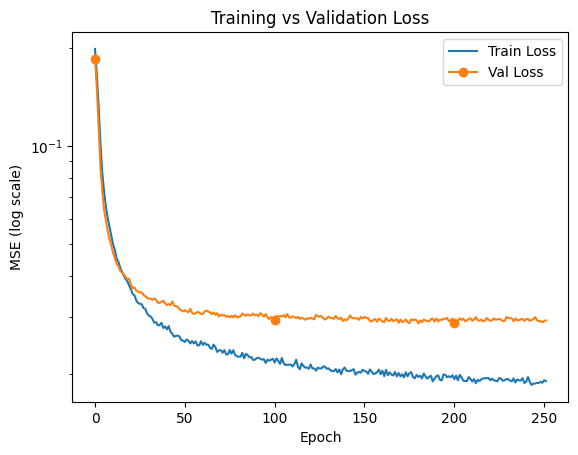

In [10]:
# 10) Plot Training & Validation Loss
plt.figure()
plt.semilogy(train_hist, label='Train Loss')
plt.semilogy(val_hist,   label='Val Loss', marker='o', markevery=100)
plt.xlabel('Epoch')
plt.ylabel('MSE (log scale)')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

## Interactive Burst

Training loss stays low but validation loss diverges — which knob do you reach for first?

- Increase **dropout** rate
- Increase **weight decay**
- Reduce **model capacity** (fewer/smaller layers)
- Add more **training data**
- Change the **train/test split** strategy

## Surrogate vs True Trajectory

Pick a random test sample and compare the predicted trajectory to the true ODE integration.

Note: this is a **direct comparison** — no rollout error accumulation, the model predicts all 64 steps at once.

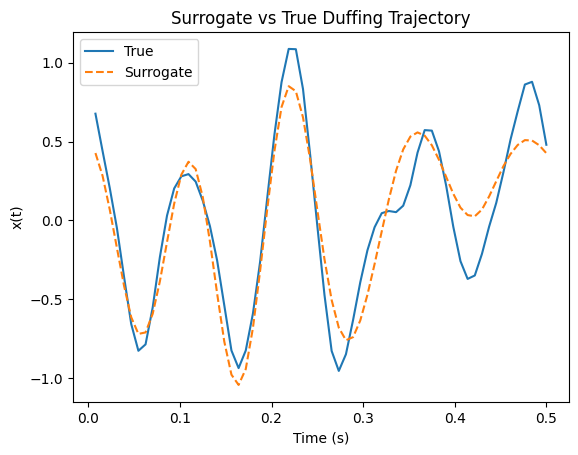

In [11]:
# 11) Compare one test case
idx = random.randrange(len(X_test))
x_in = X_test[idx:idx+1]
true = Y_test[idx].cpu().numpy()

with torch.no_grad():
    pred = model(x_in).cpu().numpy().ravel()

t_plot = t_steps[1:]  # times at x_1..x_64

plt.figure()
plt.plot(t_plot, true, label='True')
plt.plot(t_plot, pred, '--', label='Surrogate')
plt.xlabel('Time (s)')
plt.ylabel('x(t)')
plt.title('Surrogate vs True Duffing Trajectory')
plt.legend()
plt.show()

## Discussion

- Does the surrogate capture the overall shape or just approximate amplitude/phase?
- Does it perform better on Dataset 1 (random) or Dataset 2 (harmonic) samples? How would you check?
- What happens near the edges of the training distribution?

## Physics-Informed Extension

So far, the model is trained purely on labeled trajectories — "match these 64 numbers."
The equations of motion never appear in the loss; they only show up at data-generation time, hidden inside `solve_ivp`.

What if we expose the EOM directly to the optimizer?
The network outputs positions, while the Duffing equation constrains second derivatives.
We can derive $v$ and $a$ from the predicted trajectory using finite differences and require the residual

$$r_i \;=\; m\,a_i + d\,v_i + k\,x_i + \alpha k\,x_i^3 - F_i$$

to be small. The total loss becomes

$$L \;=\; L_\text{data} \;+\; \lambda\,L_\text{phys}, \qquad L_\text{phys} \;=\; \frac{1}{N}\sum_i \!\left(\frac{r_i}{F_\text{scale}}\right)^{\!2}$$

Normalizing the residual by the force scale $F_\text{scale} = 2000$ N makes $L_\text{phys}$ comparable in magnitude to the data MSE — so $\lambda \sim 0.1$–$1$ is a sensible starting range.

### Finite-Difference Stencil

Prepend the initial condition $x_0$ from the input to form the full sequence $[x_0, x_1, \dots, x_{64}]$.
At interior indices $i = 1, \dots, 63$:

$$v_i \approx \frac{x_{i+1} - x_{i-1}}{2h}, \qquad a_i \approx \frac{x_{i+1} - 2 x_i + x_{i-1}}{h^2}$$

The force at index $i$ is the corresponding input entry, de-normalized by 2000.
We skip the two endpoints — central differences need both neighbors.

In [12]:
# 12) Physics-informed residual loss
def physics_residual_loss(x_pred, x_in):
    """
    Duffing EOM residual on the predicted trajectory.
      x_pred : (B, 64)  predicted positions [x_1, ..., x_64]
      x_in   : (B, 66)  [x_0, v_0, fhat_0, ..., fhat_63]
    """
    x0    = x_in[:, 0:1]
    F_seq = x_in[:, 2:] * 2000.0

    # Full position sequence [x_0, x_1, ..., x_64]
    x_full = torch.cat([x0, x_pred], dim=1)

    # Central differences on interior indices i = 1, ..., 63
    v = (x_full[:, 2:] - x_full[:, :-2]) / (2.0 * h)
    a = (x_full[:, 2:] - 2.0 * x_full[:, 1:-1] + x_full[:, :-2]) / (h * h)
    x_int = x_full[:, 1:-1]
    F_int = F_seq[:, 1:]

    residual = m*a + damp*v + k*x_int + alpha*k*x_int**3 - F_int
    return ((residual / 2000.0)**2).mean()

### Training a PINN Variant

We instantiate a fresh model and train with the combined loss `data + λ · physics`.
Validation loss is still computed on data MSE only — this keeps the comparison against the baseline honest.

In [13]:
# 13) Train a PINN variant with combined data + physics loss
lambda_phys = 0.1

model_pinn = SurrogateMLP(2 + n_steps, dropout_rate=0.05).to(device)
optimizer_pinn = optim.AdamW(model_pinn.parameters(), lr=lr, weight_decay=weight_decay)

torch.manual_seed(432)
t0 = time.time()
train_hist_p, val_hist_p = train_loop(
    model_pinn, optimizer_pinn,
    train_loader, val_loader,
    loss_fn,
    n_epochs=2000, patience=50,
    physics_fn=physics_residual_loss,
    lambda_phys=lambda_phys,
)
print(f"PINN training finished in {time.time()-t0:.1f}s")
print(f"Final validation loss (data only): {val_hist_p[-1]:.6f}")

Early stopping @ epoch 276
PINN training finished in 5.7s
Final validation loss (data only): 0.034263


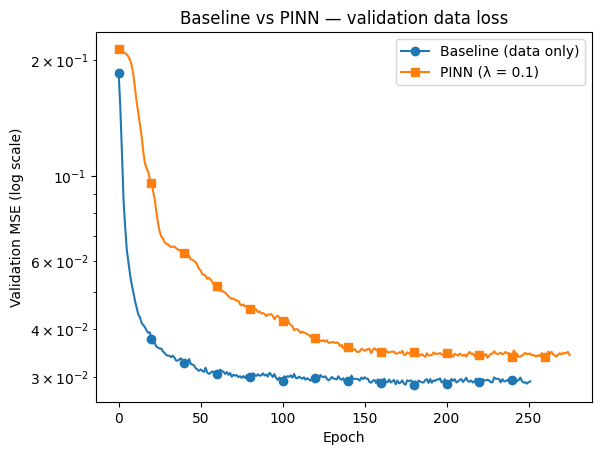

In [14]:
# 14) Learning curves: baseline vs PINN
plt.figure()
plt.semilogy(val_hist,   label='Baseline (data only)',     marker='o', markevery=20)
plt.semilogy(val_hist_p, label=f'PINN (λ = {lambda_phys})', marker='s', markevery=20)
plt.xlabel('Epoch')
plt.ylabel('Validation MSE (log scale)')
plt.legend()
plt.title('Baseline vs PINN — validation data loss')
plt.show()

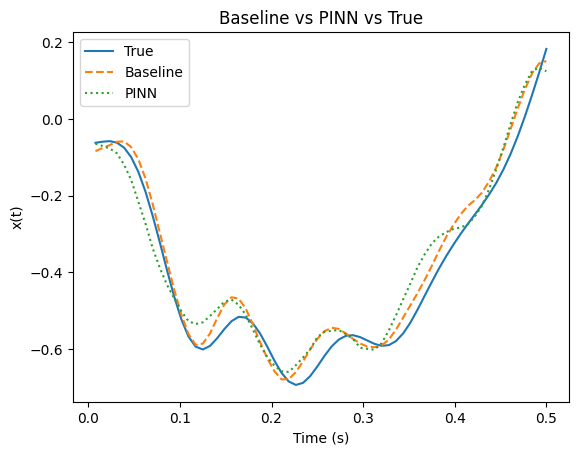

In [15]:
# 15) Trajectory comparison: baseline vs PINN on the same test sample
idx = random.randrange(len(X_test))
x_in = X_test[idx:idx+1]
true = Y_test[idx].cpu().numpy()

with torch.no_grad():
    pred_base = model(x_in).cpu().numpy().ravel()
    pred_pinn = model_pinn(x_in).cpu().numpy().ravel()

t_plot = t_steps[1:]
plt.figure()
plt.plot(t_plot, true,            label='True')
plt.plot(t_plot, pred_base, '--', label='Baseline')
plt.plot(t_plot, pred_pinn, ':',  label='PINN')
plt.xlabel('Time (s)')
plt.ylabel('x(t)')
plt.title('Baseline vs PINN vs True')
plt.legend()
plt.show()

### What just happened?

- $\lambda$ trades the two terms off. Set it to 0 and the baseline returns.
- Too small: physics has no effect.
- Too large: the model satisfies the EOM at the expense of fitting data — e.g., it picks a valid solution with the wrong initial conditions.

Physics also acts as a free regularizer on regions where data labels are sparse or noisy.
If you cut `N1` and `N2`, the PINN should degrade more gracefully than the baseline.

### Why does the PINN's validation loss sit a bit *higher* than the baseline?

This sometimes confuses on first read. The validation loss we report is **data MSE only** — the physics term is not added back in during evaluation (re-check `train_loop`). So a higher PINN val loss is *not* a double-counting artifact.

It just reflects the trade-off the optimizer made: with $\lambda > 0$ the network spends some of its capacity satisfying the EOM residual, which it can't also spend on minimizing data MSE. The PINN is intentionally a worse pure-MSE fitter — in exchange for trajectories that are more physically consistent (smoother, better second derivatives, gentler extrapolation). Whether that's a good trade depends on what you do with the model downstream.

> **Don't over-generalize from this.** The baseline wins here mainly because the data is plentiful, clean, and noise-free, so there is little left for the physics term to add. PINNs typically pay off when data is *sparse or noisy* — exactly what the `N1 = N2 = 200` experiment below is meant to expose.

### Try

- Sweep `lambda_phys ∈ {0, 0.01, 0.1, 1.0, 10.0}` and plot final validation loss.
- Cut training data to `N1 = N2 = 200` and rerun both models. Where does PINN help most?

## Extrapolation: Where the Surrogate Fails

A trained model has no defense against inputs outside its training distribution.
The black-box surrogate above was trained on:
- Forces with amplitude in $[-2000,\,2000]$ N
- Harmonic frequencies in $[0,\,4\pi]$ rad/s
- Initial conditions in $[-1,\,1]$

What happens when we step outside?

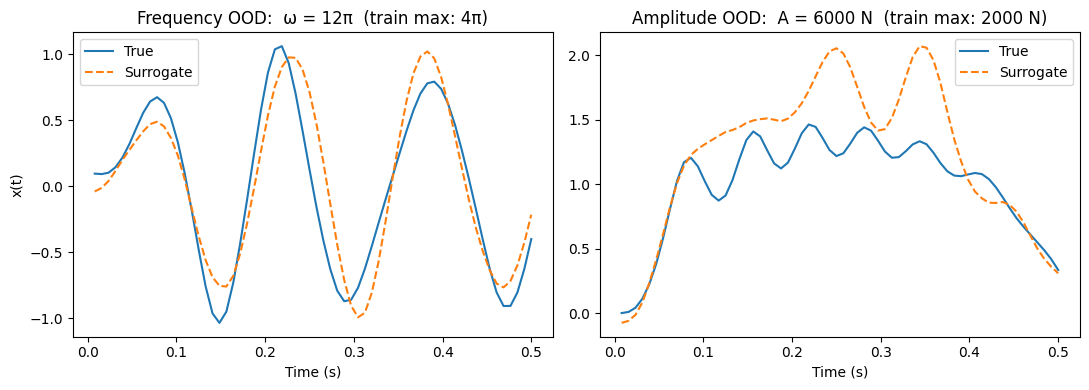

In [16]:
# 16) Out-of-distribution tests: where the surrogate fails
model.eval()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) Frequency OOD — harmonic at 3× the training max frequency
A_a, omega_a = 1000.0, 12 * np.pi
F_a = A_a * np.sin(omega_a * t_steps[:-1])
inp_a = np.zeros(2 + n_steps, dtype=np.float32)
inp_a[0], inp_a[1] = 0.1, 0.0
inp_a[2:] = F_a / 2000.0
with torch.no_grad():
    pred_a = model(torch.from_numpy(inp_a).unsqueeze(0).to(device)).cpu().numpy().ravel()
true_a = solve_ivp(lambda t, y: duffing_rhs(t, y, F_a),
                   (0, T), [0.1, 0.0], t_eval=t_steps, method='RK45').y[0, 1:]
axes[0].plot(t_steps[1:], true_a,       label='True')
axes[0].plot(t_steps[1:], pred_a, '--', label='Surrogate')
axes[0].set_title(f'Frequency OOD:  ω = 12π  (train max: 4π)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('x(t)'); axes[0].legend()

# (b) Amplitude OOD — harmonic at 3× the training max amplitude
A_b = 6000.0
F_b = A_b * np.sin(2 * np.pi * t_steps[:-1])
inp_b = np.zeros(2 + n_steps, dtype=np.float32)
inp_b[2:] = F_b / 2000.0
with torch.no_grad():
    pred_b = model(torch.from_numpy(inp_b).unsqueeze(0).to(device)).cpu().numpy().ravel()
true_b = solve_ivp(lambda t, y: duffing_rhs(t, y, F_b),
                   (0, T), [0.0, 0.0], t_eval=t_steps, method='RK45').y[0, 1:]
axes[1].plot(t_steps[1:], true_b,       label='True')
axes[1].plot(t_steps[1:], pred_b, '--', label='Surrogate')
axes[1].set_title(f'Amplitude OOD:  A = 6000 N  (train max: 2000 N)')
axes[1].set_xlabel('Time (s)'); axes[1].legend()

plt.tight_layout()
plt.show()

### Validity envelope

The surrogate silently produces a plausible-looking but wrong trajectory.
There is no warning, no "I don't know" flag — only the comparison against the solver tells you anything is off.

**For an MBD practitioner: the training distribution *is* the validity envelope of the surrogate.**
Treat it like the bounds on a fitted polynomial — extrapolation is at your own risk.

Mitigations:
- Generate data covering the full operating range you care about.
- Monitor inputs at inference and reject (or fall back to the solver) when outside the training box.
- Combine with grey-box approaches (see 2-1) — known physics keeps you sane outside the learned envelope.

## Speedup: Surrogate vs. Solver

So why bother with a surrogate at all? Because **inference is faster than integration**.
For the 64-step Duffing trajectory we benchmark both paths below. Run the cell a couple of times — the first solver call may include JIT/cache warm-up.

In [17]:
# 17) Timing: solver vs. surrogate, per trajectory
import time

n_runs = 100
rng_t = np.random.default_rng(0)

t0 = time.perf_counter()
for _ in range(n_runs):
    F_rnd = rng_t.uniform(-2000, 2000, n_steps)
    _ = solve_ivp(lambda t, y: duffing_rhs(t, y, F_rnd),
                  (0, T), [0.1, 0.0], t_eval=t_steps, method='RK45')
solver_t = (time.perf_counter() - t0) / n_runs

model.eval()
t0 = time.perf_counter()
for _ in range(n_runs):
    F_rnd = rng_t.uniform(-2000, 2000, n_steps).astype(np.float32) / 2000.0
    inp = np.zeros(2 + n_steps, dtype=np.float32)
    inp[0] = 0.1
    inp[2:] = F_rnd
    with torch.no_grad():
        _ = model(torch.from_numpy(inp).unsqueeze(0).to(device))
surrogate_t = (time.perf_counter() - t0) / n_runs

print(f'Solver:    {solver_t   *1000:7.2f} ms per trajectory')
print(f'Surrogate: {surrogate_t*1000:7.2f} ms per trajectory')
print(f'Speedup:   {solver_t / surrogate_t:.1f}x')

Solver:       6.25 ms per trajectory
Surrogate:    0.04 ms per trajectory
Speedup:   173.1x


### When the speedup matters

For a one-off forward simulation, the solver is fine. The surrogate pays off when you need to call the dynamics **many times** with **similar inputs**:

- **Optimization loops** — control synthesis, parameter calibration, shape design.
- **Monte Carlo / uncertainty propagation** — thousands of runs per design point.
- **Batched evaluation** — a GPU runs hundreds of surrogates in parallel; the solver doesn't parallelize across independent trajectories without extra work.

For a system this small the speedup is moderate. For coupled multibody systems with stiff dynamics and many DOF, the ratio grows quickly — that's where surrogate modeling becomes operationally useful.

## Your Turn

Re-run the training and trajectory comparison after each change.

### Try (5 min)

Reduce dataset sizes: change `N1 = N2 = 500` and regenerate.
- Does the model still capture the trajectory shape?
- Does it overfit (train loss much lower than val loss)?

### Extend (5–10 min)

Change the architecture: add a fourth hidden layer to get `128 → 64 → 32 → 16 → 64`.

In `SurrogateMLP`, add:
```python
nn.Linear(32, 16),
nn.ReLU(),
nn.Dropout(dropout_rate),
```
before the final output layer.

Does deeper help or hurt here?

### Explore (open-ended)

Train using **only Dataset 1** (random forces, no harmonics), then test on Dataset 2 samples.

- Does the model generalize across forcing types?
- What does failure look like in the trajectory plot?

> **Tip:** After changing data generation, re-run from the combine+split cell onwards. The training loop and trajectory comparison cells stay the same.

## What's Next?

**Session 2-3** — Automated Machine Learning  

We just used fixed hyperparameters (`lr=2e-3`, `hidden=[128,64,32]`, etc.).  
How do we know they are good? Could systematic search find something better?

In 2-3 we run a **grid search over 64 hyperparameter configurations** and use box plots to understand which choices actually matter.